<a href="https://colab.research.google.com/github/dhruthirs/adversarial-resilience/blob/main/notebooks/cifar10_resnet18_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Baseline Evaluation: ResNet18 on CIFAR-10 under FGSM & PGD

This is your Objective 1 notebook: evaluate a real SOTA architecture on a real dataset, then attack it.

**Reuse plan:** this same notebook structure works for your other 2 architectures (MobileNetV2, ViT) — just swap the model definition cell (Step D) and re-run everything else unchanged. Keep results from each run in the shared results table at the bottom (Step I) so you build one master comparison across all models.

## Step A: Install the attack library

In [10]:
!pip install torchattacks -q

## Step B: Imports and device setup

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchattacks
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Step C: Load CIFAR-10

60,000 color images (32x32), 10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck.
This is a meaningfully harder dataset than MNIST — real objects, real colors, more visual complexity.

In [12]:
transform = transforms.Compose([transforms.ToTensor()])

!wget -q https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz -O cifar10.tgz
!tar -xzf cifar10.tgz

import torchvision.datasets as datasets

train_set = datasets.ImageFolder(root='cifar10/train', transform=transform)
test_set = datasets.ImageFolder(root='cifar10/test', transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

classes = train_set.classes
print(f'Train samples: {len(train_set)}, Test samples: {len(test_set)}')
print('Classes:', classes)

Train samples: 50000, Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Step D: Define ResNet18 (adapted for CIFAR-10's small 32x32 images)

Standard torchvision ResNet18 expects 224x224 ImageNet images. We modify the first layers so it works well on CIFAR-10's smaller images — this is the standard adaptation used across adversarial ML research code.

**To swap architectures later:** replace just this cell. For MobileNetV2: `torchvision.models.mobilenet_v2(num_classes=10)`. For a ViT, look up `timm` library's `vit_tiny_patch16_224` (needs image resizing to 224x224, more involved — ask me when you get there).

In [13]:
def build_resnet18_cifar():
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    # swap the first conv layer: smaller kernel, no aggressive downsampling (since images are only 32x32)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()  # remove the maxpool that would shrink our already-small image too fast
    return model

model = build_resnet18_cifar().to(device)
print('Model ready. Total parameters:', sum(p.numel() for p in model.parameters()))

Model ready. Total parameters: 11173962


## Step E: Train it

This takes longer than MNIST (~1-2 minutes per epoch on Colab's free GPU). 10 epochs gets you roughly 75-80% clean accuracy — good enough for a mini project baseline. If you have time, more epochs = better accuracy, but diminishing returns after ~15-20.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 10  # increase later if you want higher clean accuracy; 10 is a reasonable baseline

model.train()
start = time.time()
for epoch in range(EPOCHS):
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{EPOCHS} - loss: {running_loss/len(train_loader):.4f}')

print(f'Training done in {(time.time()-start)/60:.1f} minutes.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Epoch 1/10 - loss: 1.1855
Epoch 2/10 - loss: 0.7058
Epoch 3/10 - loss: 0.5224
Epoch 4/10 - loss: 0.3982
Epoch 5/10 - loss: 0.2929
Epoch 6/10 - loss: 0.2119
Epoch 7/10 - loss: 0.1551
Epoch 8/10 - loss: 0.1049
Epoch 9/10 - loss: 0.0941
Epoch 10/10 - loss: 0.0727
Training done in 9.8 minutes.


In [ ]:
torch.save(model.state_dict(), 'resnet18_cifar10.pth')  # change filename per model, e.g. mobilenet_cifar10.pth

from google.colab import files
files.download('resnet18_cifar10.pth')

## Step F: Measure CLEAN accuracy (no attack)

In [15]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

clean_acc = evaluate(model, test_loader)
print(f'Clean accuracy (no attack): {clean_acc:.2f}%')

Clean accuracy (no attack): 82.02%


## Step G: Run FGSM attack

CIFAR-10 images use the same 0-1 pixel scale as MNIST, so the same eps intuition applies. eps=8/255 (≈ 0.031) is the standard value used in most adversarial ML papers for CIFAR-10 — small enough to stay fairly imperceptible.

In [16]:
eps_fgsm = 8/255  # standard CIFAR-10 benchmark value (~0.031)

atk_fgsm = torchattacks.FGSM(model, eps=eps_fgsm)

model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = atk_fgsm(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

fgsm_accuracy = 100 * correct / total
print(f'Accuracy UNDER FGSM attack (eps={eps_fgsm:.3f}): {fgsm_accuracy:.2f}%')
print(f'FGSM Attack Success Rate (ASR): {100 - fgsm_accuracy:.2f}%')

Accuracy UNDER FGSM attack (eps=0.031): 3.15%
FGSM Attack Success Rate (ASR): 96.85%


## Step H: Run PGD attack

Standard CIFAR-10 PGD benchmark settings: eps=8/255, alpha=2/255, steps=10 (or 20 for a stronger/more thorough attack — used in most published papers).

In [17]:
eps_pgd = 8/255
alpha_pgd = 2/255
steps_pgd = 20

atk_pgd = torchattacks.PGD(model, eps=eps_pgd, alpha=alpha_pgd, steps=steps_pgd)

model.eval()
correct, total = 0, 0
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    adv_images = atk_pgd(images, labels)

    outputs = model(adv_images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

pgd_accuracy = 100 * correct / total
print(f'Accuracy UNDER PGD attack (eps={eps_pgd:.3f}): {pgd_accuracy:.2f}%')
print(f'PGD Attack Success Rate (ASR): {100 - pgd_accuracy:.2f}%')

Accuracy UNDER PGD attack (eps=0.031): 0.00%
PGD Attack Success Rate (ASR): 100.00%


## Step I: Results summary (record this in your shared team doc)

Copy this printed table into your team's results tracker every time you run this notebook for a new architecture.

In [18]:
print('=' * 55)
print('BASELINE RESULTS — Model: ResNet18 | Dataset: CIFAR-10')
print('=' * 55)
print(f'{"Condition":<20}{"Accuracy":<12}{"ASR":<10}')
print('-' * 55)
print(f'{"Clean":<20}{clean_acc:<12.2f}{"-":<10}')
print(f'{"FGSM (eps=8/255)":<20}{fgsm_accuracy:<12.2f}{100-fgsm_accuracy:<10.2f}')
print(f'{"PGD (eps=8/255)":<20}{pgd_accuracy:<12.2f}{100-pgd_accuracy:<10.2f}')
print('=' * 55)

BASELINE RESULTS — Model: ResNet18 | Dataset: CIFAR-10
Condition           Accuracy    ASR       
-------------------------------------------------------
Clean               82.02       -         
FGSM (eps=8/255)    3.15        96.85     
PGD (eps=8/255)     0.00        100.00    


## What to do next

1. Run this notebook fully once for ResNet18 (this file, as-is) — record the Step I results.
2. Duplicate this notebook, swap only Step D for MobileNetV2, re-run everything — record results again.
3. Repeat for your third architecture.
4. Once all 3 models have results, you have your full Objective 1 baseline table — ready to move to Objective 2 (defense strategy).

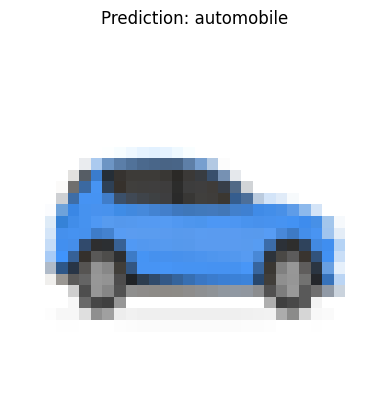

In [19]:
from PIL import Image
import torchvision.transforms as transforms

def predict_my_image(image_path, model):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((32, 32))

    transform = transforms.ToTensor()
    img_tensor = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(dim=1).item()

    plt.imshow(img)
    plt.title(f'Prediction: {classes[pred]}')
    plt.axis('off')
    plt.show()

    return img_tensor, pred

# usage — upload your photo via the folder icon first, then copy its path here:
img_tensor, pred = predict_my_image('/car.png', model)

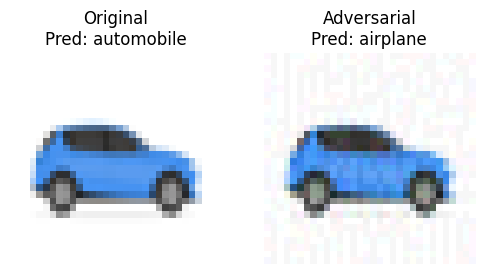

In [20]:
label_tensor = torch.tensor([pred]).to(device)
adv_img = atk_fgsm(img_tensor, label_tensor)

with torch.no_grad():
    adv_pred = model(adv_img).argmax(dim=1).item()

fig, axes = plt.subplots(1, 2, figsize=(6,3))
axes[0].imshow(img_tensor.squeeze().permute(1,2,0).cpu())
axes[0].set_title(f'Original\nPred: {classes[pred]}')
axes[0].axis('off')
axes[1].imshow(adv_img.squeeze().detach().permute(1,2,0).cpu())
axes[1].set_title(f'Adversarial\nPred: {classes[adv_pred]}')
axes[1].axis('off')
plt.show()